In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# graphing
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# machine learning
import sklearn
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.utils import compute_sample_weight
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

import xgboost
from xgboost import XGBClassifier

import lightgbm
from lightgbm import LGBMClassifier

# hyperparameter tuning
import optuna
import skopt


# install and import openfe
!pip install openfe

import openfe
from openfe import transform, OpenFE


In [2]:
# get python package versions
print('numpy version is: {}'.format(np.__version__))
print('pandas version is: {}'.format(pd.__version__))
print('matplotlib version is: {}'.format(matplotlib.__version__))
print('seaborn version is: {}'.format(sns.__version__))
print('scikit-learn version is: {}'.format(sklearn.__version__))
print('xgboost version is: {}'.format(xgboost.__version__))
print('lightgbm version is: {}'.format(lightgbm.__version__))
print('openfe version is: {}'.format(openfe.__version__))

numpy version is: 2.0.2
pandas version is: 2.2.2
matplotlib version is: 3.10.0
seaborn version is: 0.13.2
scikit-learn version is: 1.6.1
xgboost version is: 3.1.0
lightgbm version is: 4.6.0
openfe version is: 0.0.12


In [3]:
# load in the training data
data = pd.read_csv('/kaggle/input/playground-series-s4e6/train.csv')
print(data.head())

   id  Marital status  Application mode  Application order  Course  \
0   0               1                 1                  1    9238   
1   1               1                17                  1    9238   
2   2               1                17                  2    9254   
3   3               1                 1                  3    9500   
4   4               1                 1                  2    9500   

   Daytime/evening attendance  Previous qualification  \
0                           1                       1   
1                           1                       1   
2                           1                       1   
3                           1                       1   
4                           1                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  ...  \
0                           126.0            1                       1  ...   
1                           125.0            1                      19  ...   

In [4]:
# check the column information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76518 entries, 0 to 76517
Data columns (total 38 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   id                                              76518 non-null  int64  
 1   Marital status                                  76518 non-null  int64  
 2   Application mode                                76518 non-null  int64  
 3   Application order                               76518 non-null  int64  
 4   Course                                          76518 non-null  int64  
 5   Daytime/evening attendance                      76518 non-null  int64  
 6   Previous qualification                          76518 non-null  int64  
 7   Previous qualification (grade)                  76518 non-null  float64
 8   Nacionality                                     76518 non-null  int64  
 9   Mother's qualification                 

No nulls.  all features are numeric.  Only target is categorical.

In [5]:
# look at the statistics for the training data
data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,76518.0,38258.500000,22088.988286,0.00,19129.250000,38258.500000,57387.750000,76517.000
Marital status,76518.0,1.111934,0.441669,1.00,1.000000,1.000000,1.000000,6.000
Application mode,76518.0,16.054419,16.682337,1.00,1.000000,17.000000,39.000000,53.000
Application order,76518.0,1.644410,1.229645,0.00,1.000000,1.000000,2.000000,9.000
Course,76518.0,9001.286377,1803.438531,33.00,9119.000000,9254.000000,9670.000000,9991.000
Daytime/evening attendance,76518.0,0.915314,0.278416,0.00,1.000000,1.000000,1.000000,1.000
Previous qualification,76518.0,3.658760,8.623774,1.00,1.000000,1.000000,1.000000,43.000
Previous qualification (grade),76518.0,132.378766,10.995328,95.00,125.000000,133.100000,140.000000,190.000
Nacionality,76518.0,1.226600,3.392183,1.00,1.000000,1.000000,1.000000,109.000
Mother's qualification,76518.0,19.837633,15.399456,1.00,1.000000,19.000000,37.000000,44.000


In [6]:
# function to plot histogram and boxplot
def hist_box_fn(df1, col1):
    fig0, ax0= plt.subplots(1, 2, figsize= (8, 4), gridspec_kw= {'width_ratios':[2, 1]})
    fig0.suptitle(col1)
    plt.subplots_adjust(wspace= 0.5)
    ax0[0].hist(df1[col1])
    # median
    ax0[0].axvline(df1[col1].median(), linewidth= 2, color= 'g')
    # average
    ax0[0].axvline(df1[col1].mean(), linewidth= 2, color= 'k')
    # formatting
    ax0[0].set_xlabel(col1)
    ax0[0].set_ylabel('Counts')
    ax0[1].boxplot(df1[col1])
    ax0[1].set_ylabel(col1)
    # add skew as text
    skew_str= "skew: " + str(round(df1[col1].skew(), 3))
    ax0[0].text(0.5, 0.9, skew_str, transform= ax0[0].transAxes)
    return fig0
    

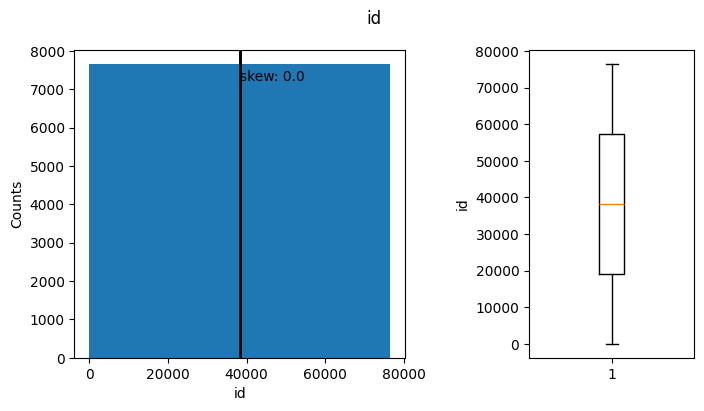

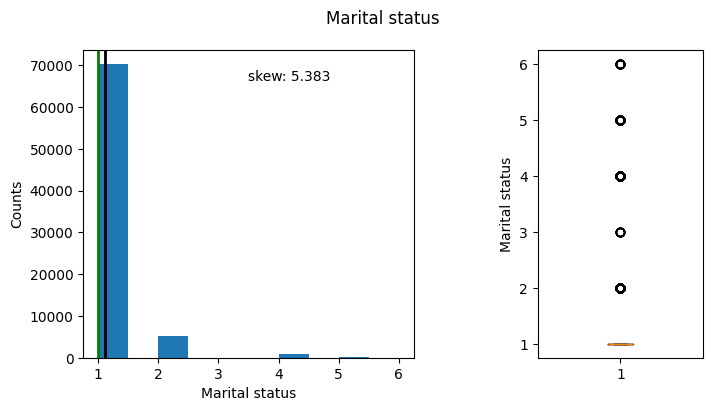

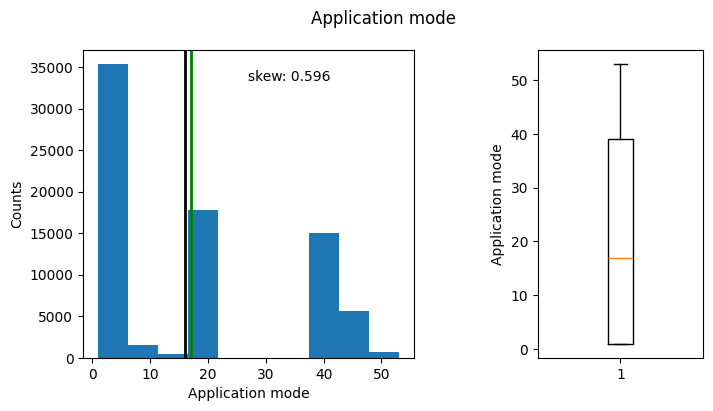

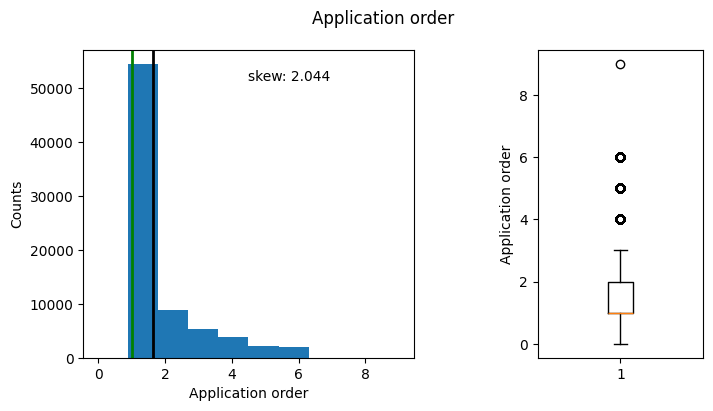

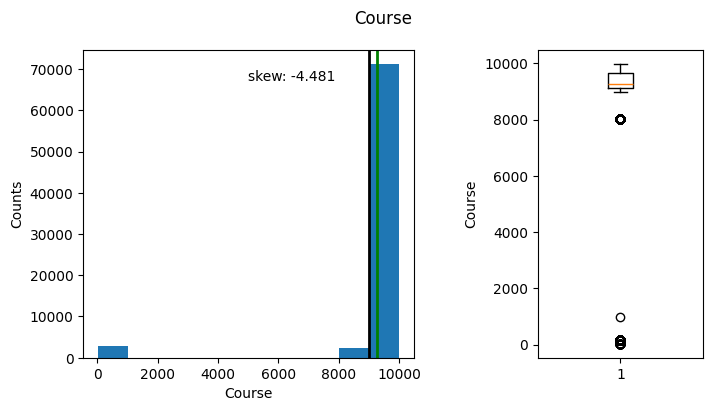

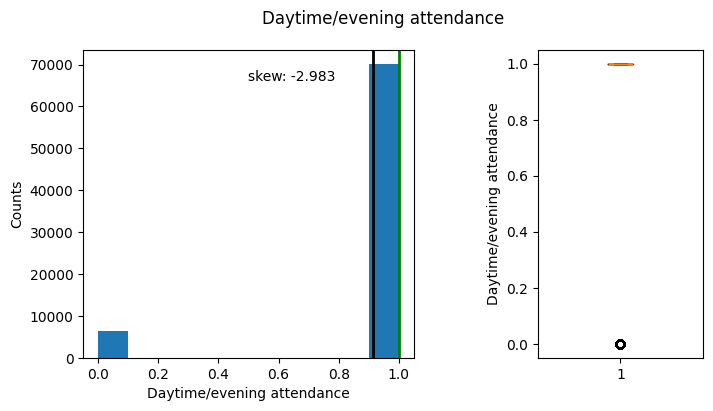

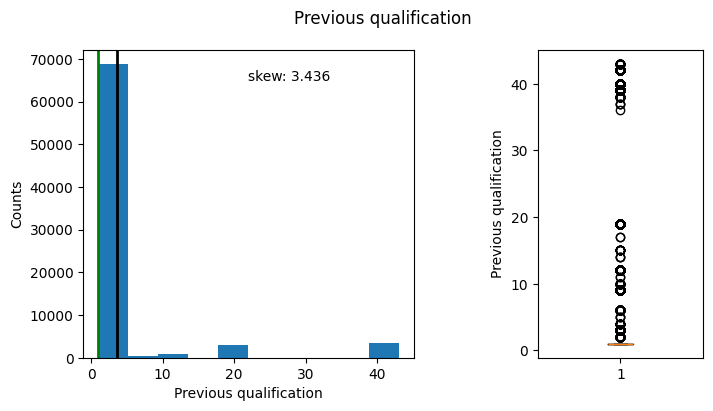

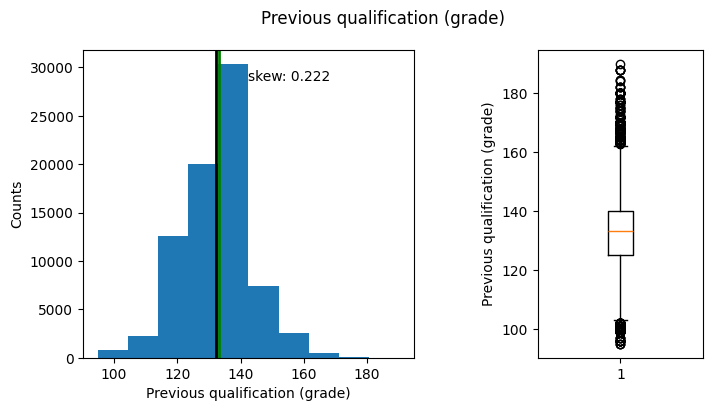

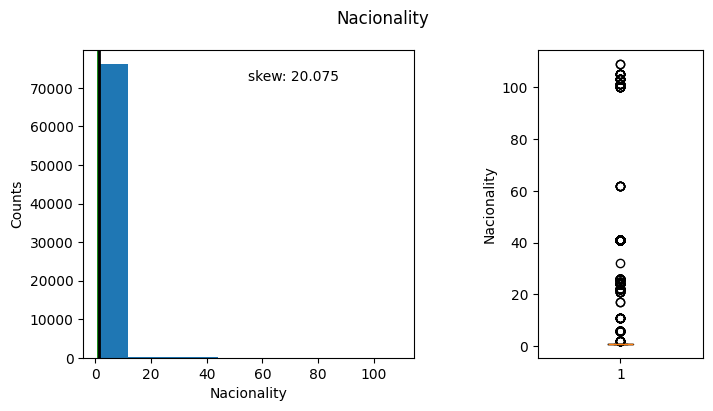

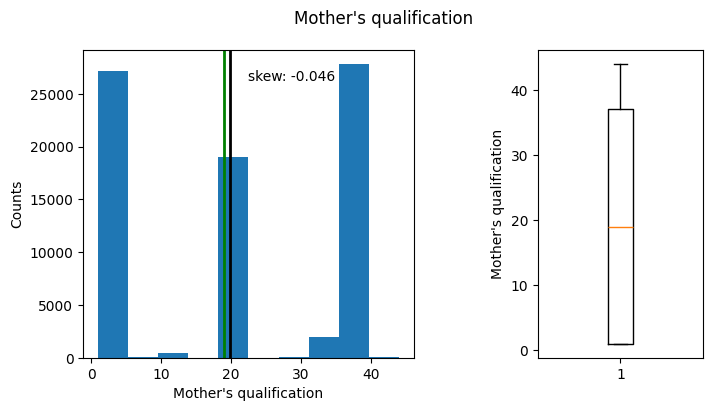

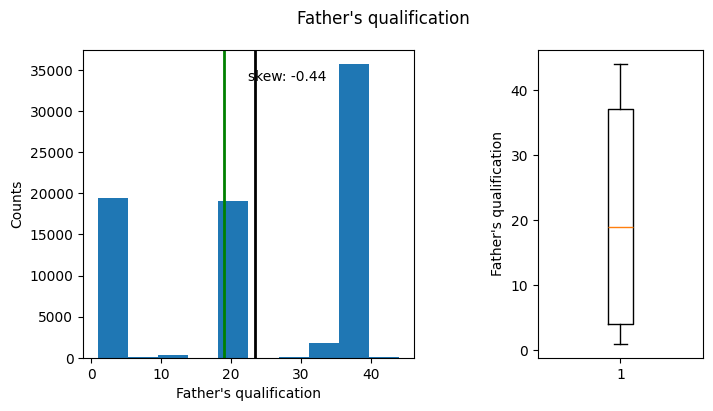

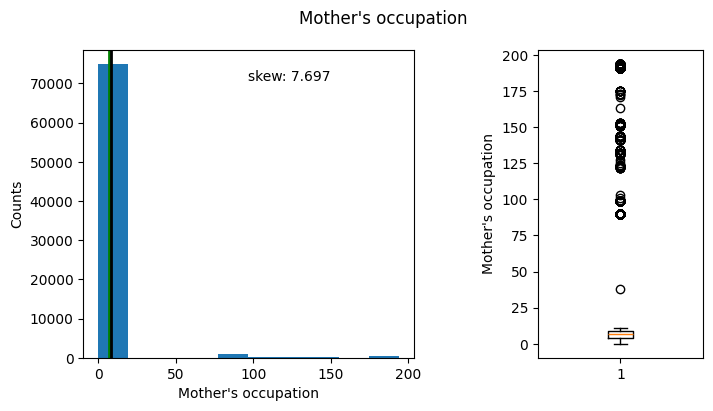

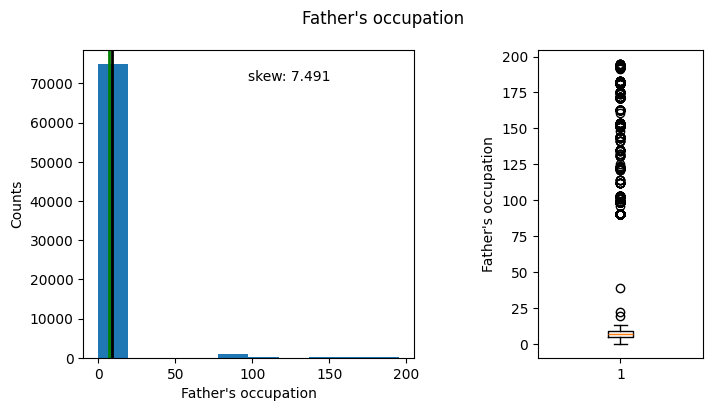

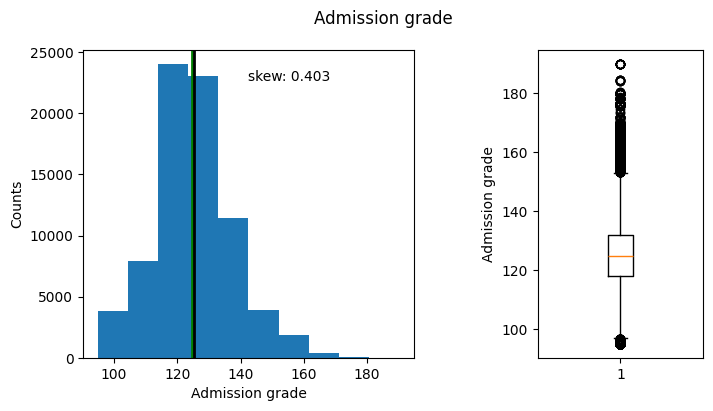

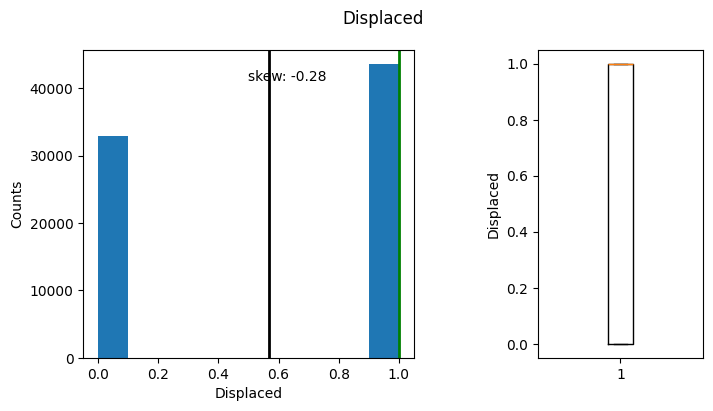

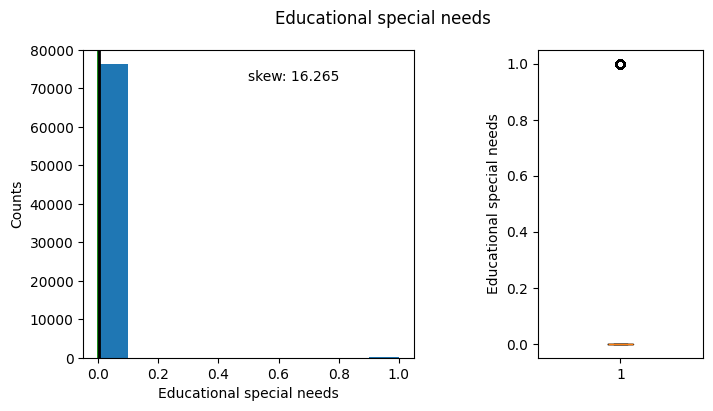

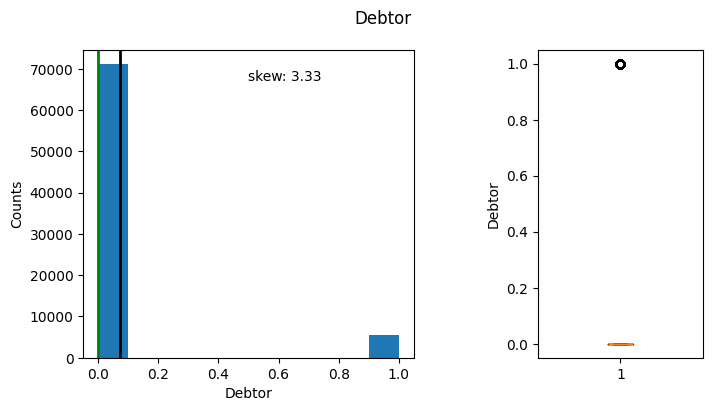

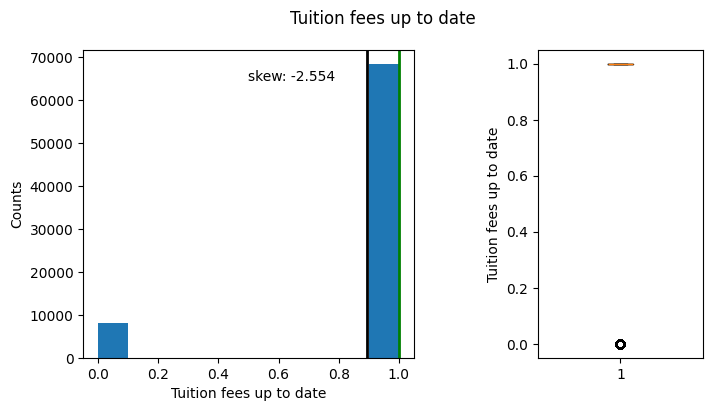

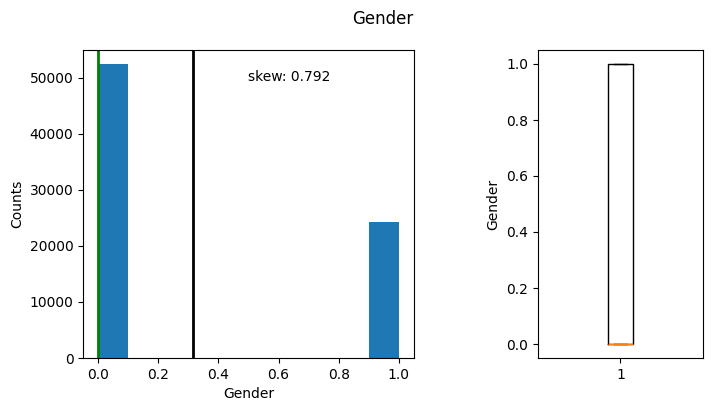

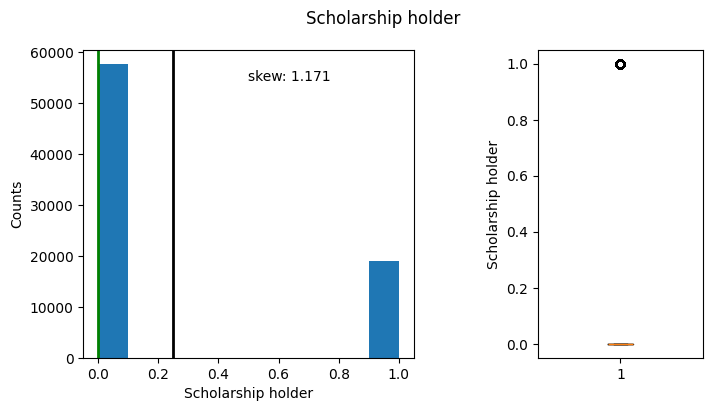

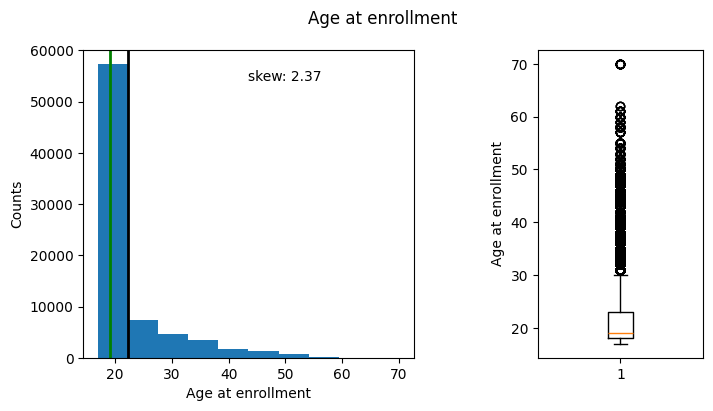

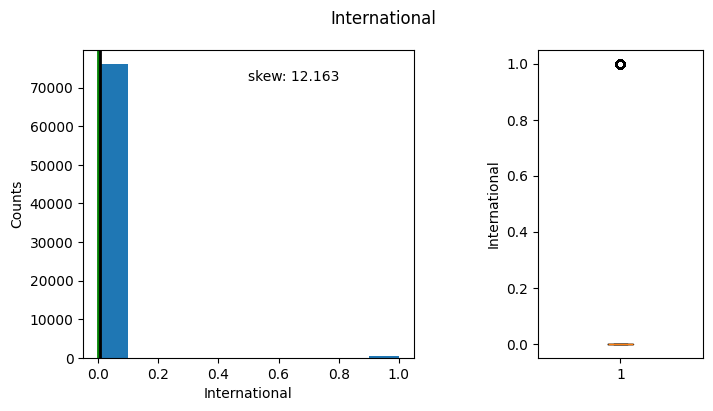

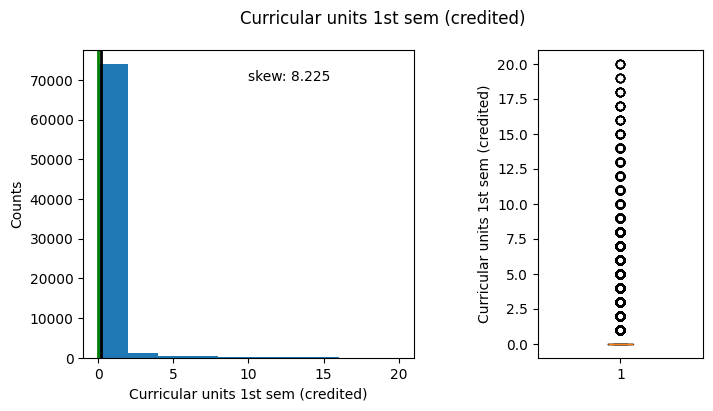

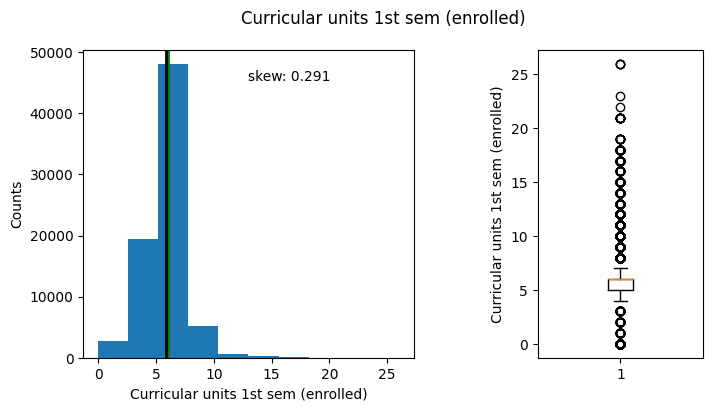

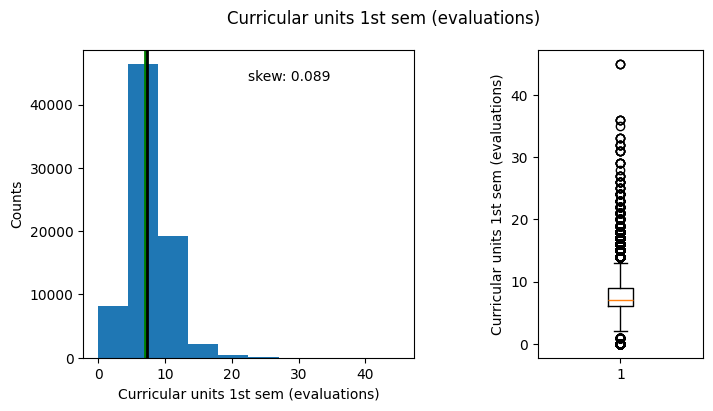

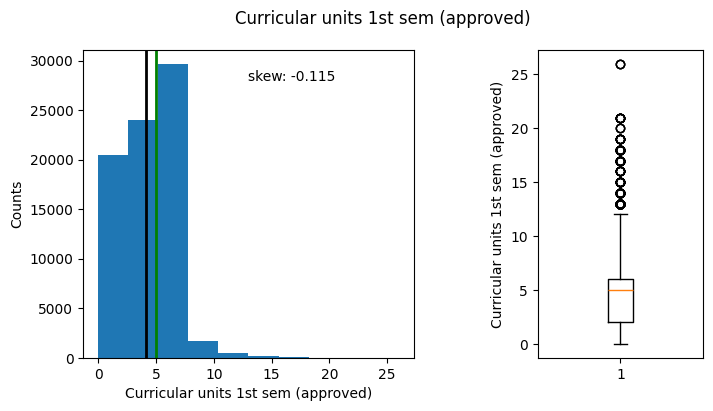

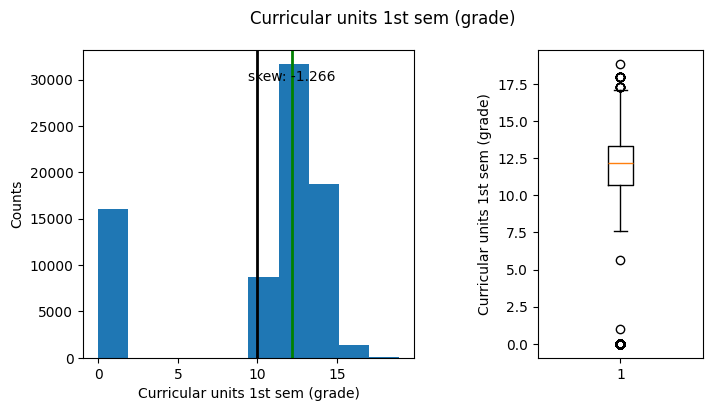

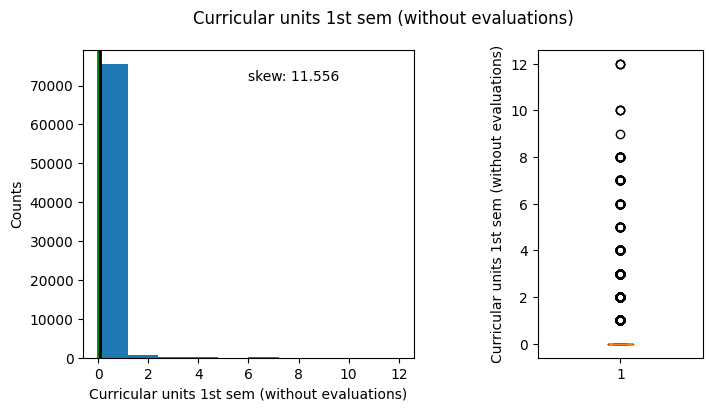

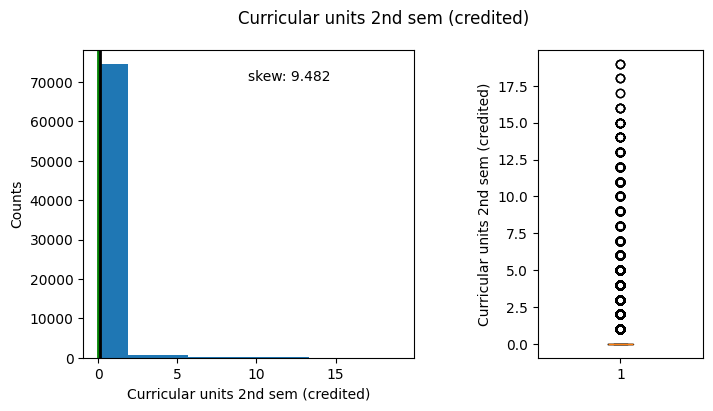

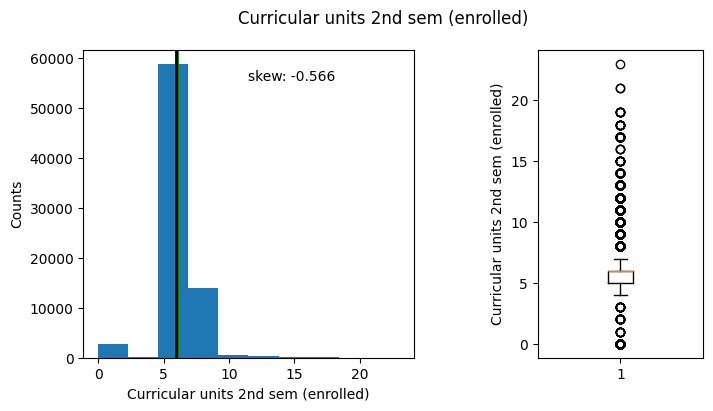

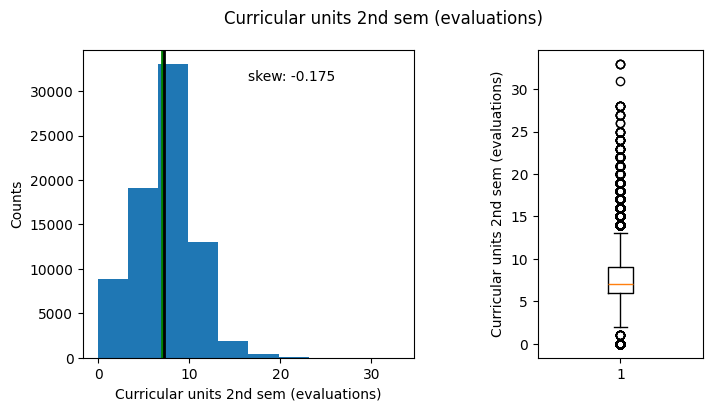

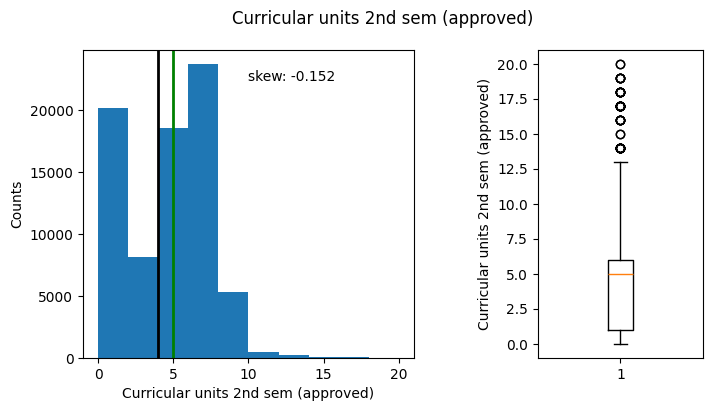

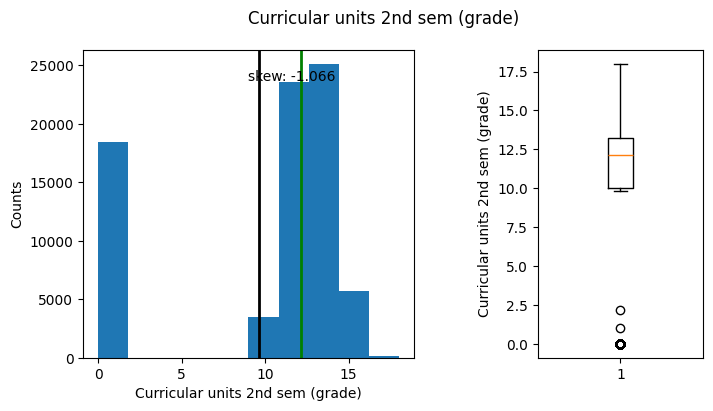

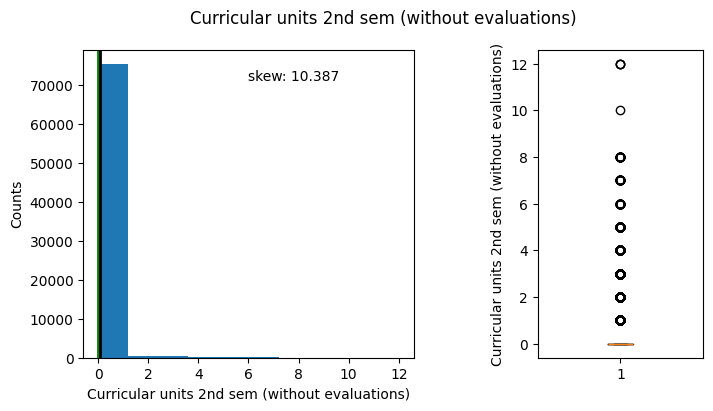

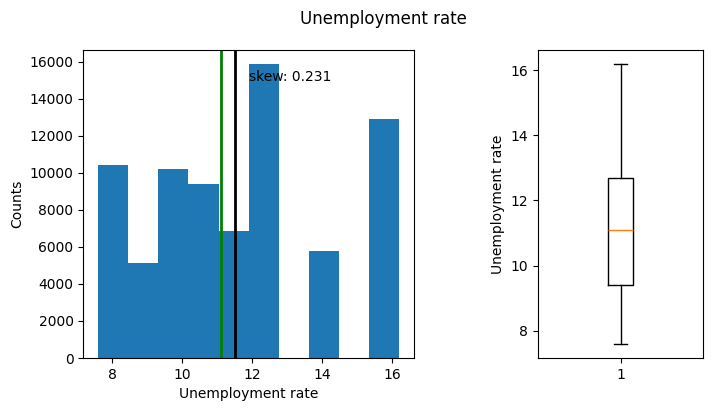

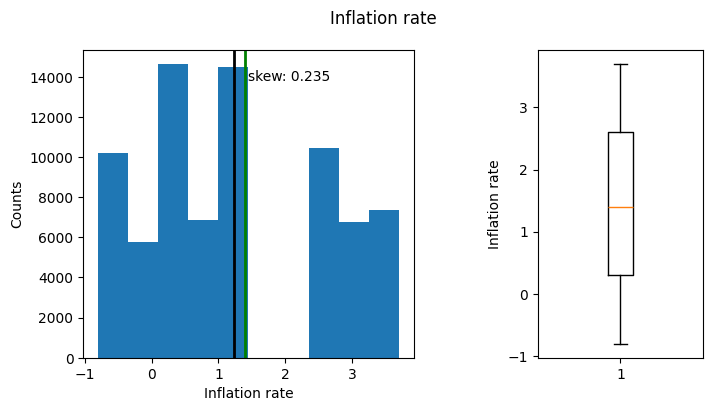

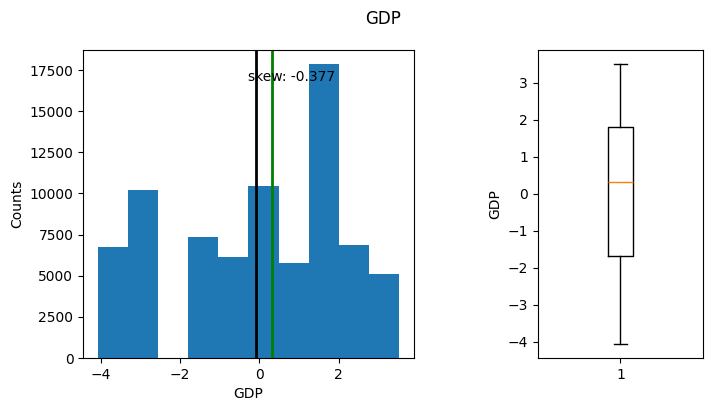

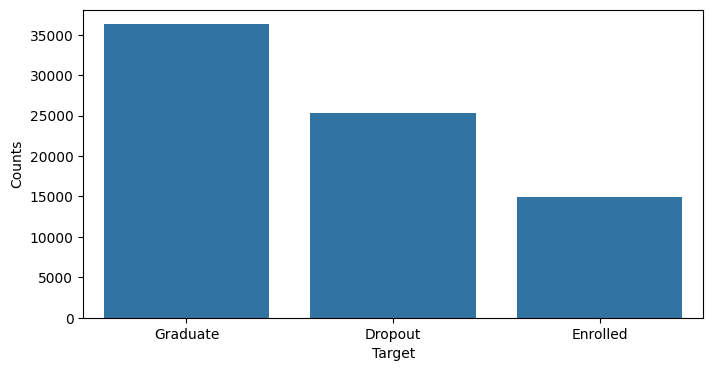

In [7]:
# plot features and target
for i in data.columns:
    if i != 'Target':
        fig0= hist_box_fn(data, i)
        plt.show(fig0)
        plt.pause(0.01)
        plt.close(fig0)
    else:
        fig1= plt.figure(figsize= (8, 4))
        ax1= plt.gca()
        ax1.set_ylabel('Counts')
        ax1.set_xlabel('Target')
        sns.countplot(data= data, x= 'Target')

the classes are imbalanced.  First try: use class_weight, second_try undersample majority

In [8]:
# split x train and y train
y_train= data['Target']
x_train= data.drop(['Target'], axis= 1)

# look at new data frames
print(x_train.head())
print('shape of x train is: {}'.format(x_train.shape))

print('-'*80)
print(y_train.head())
print('shape of y train is: {}'.format(y_train.shape))

   id  Marital status  Application mode  Application order  Course  \
0   0               1                 1                  1    9238   
1   1               1                17                  1    9238   
2   2               1                17                  2    9254   
3   3               1                 1                  3    9500   
4   4               1                 1                  2    9500   

   Daytime/evening attendance  Previous qualification  \
0                           1                       1   
1                           1                       1   
2                           1                       1   
3                           1                       1   
4                           1                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  ...  \
0                           126.0            1                       1  ...   
1                           125.0            1                      19  ...   

In [9]:
# remove spaces and characters from feature names

x_train.columns= x_train.columns.str.replace(" ", "_")
x_train.columns= x_train.columns.str.replace("(", "")
x_train.columns= x_train.columns.str.replace(")", "")
x_train.columns= x_train.columns.str.replace("'", "")
x_train.columns= x_train.columns.str.replace("/", "")

In [10]:
# label encode the target

encoder= LabelEncoder()

# fit and transform training target
y_train= encoder.fit_transform(y_train)
y_train= pd.Series(y_train, name= 'Target')

# look at encoded dataframe
print(y_train.head())

0    2
1    0
2    0
3    1
4    2
Name: Target, dtype: int64


<Axes: >

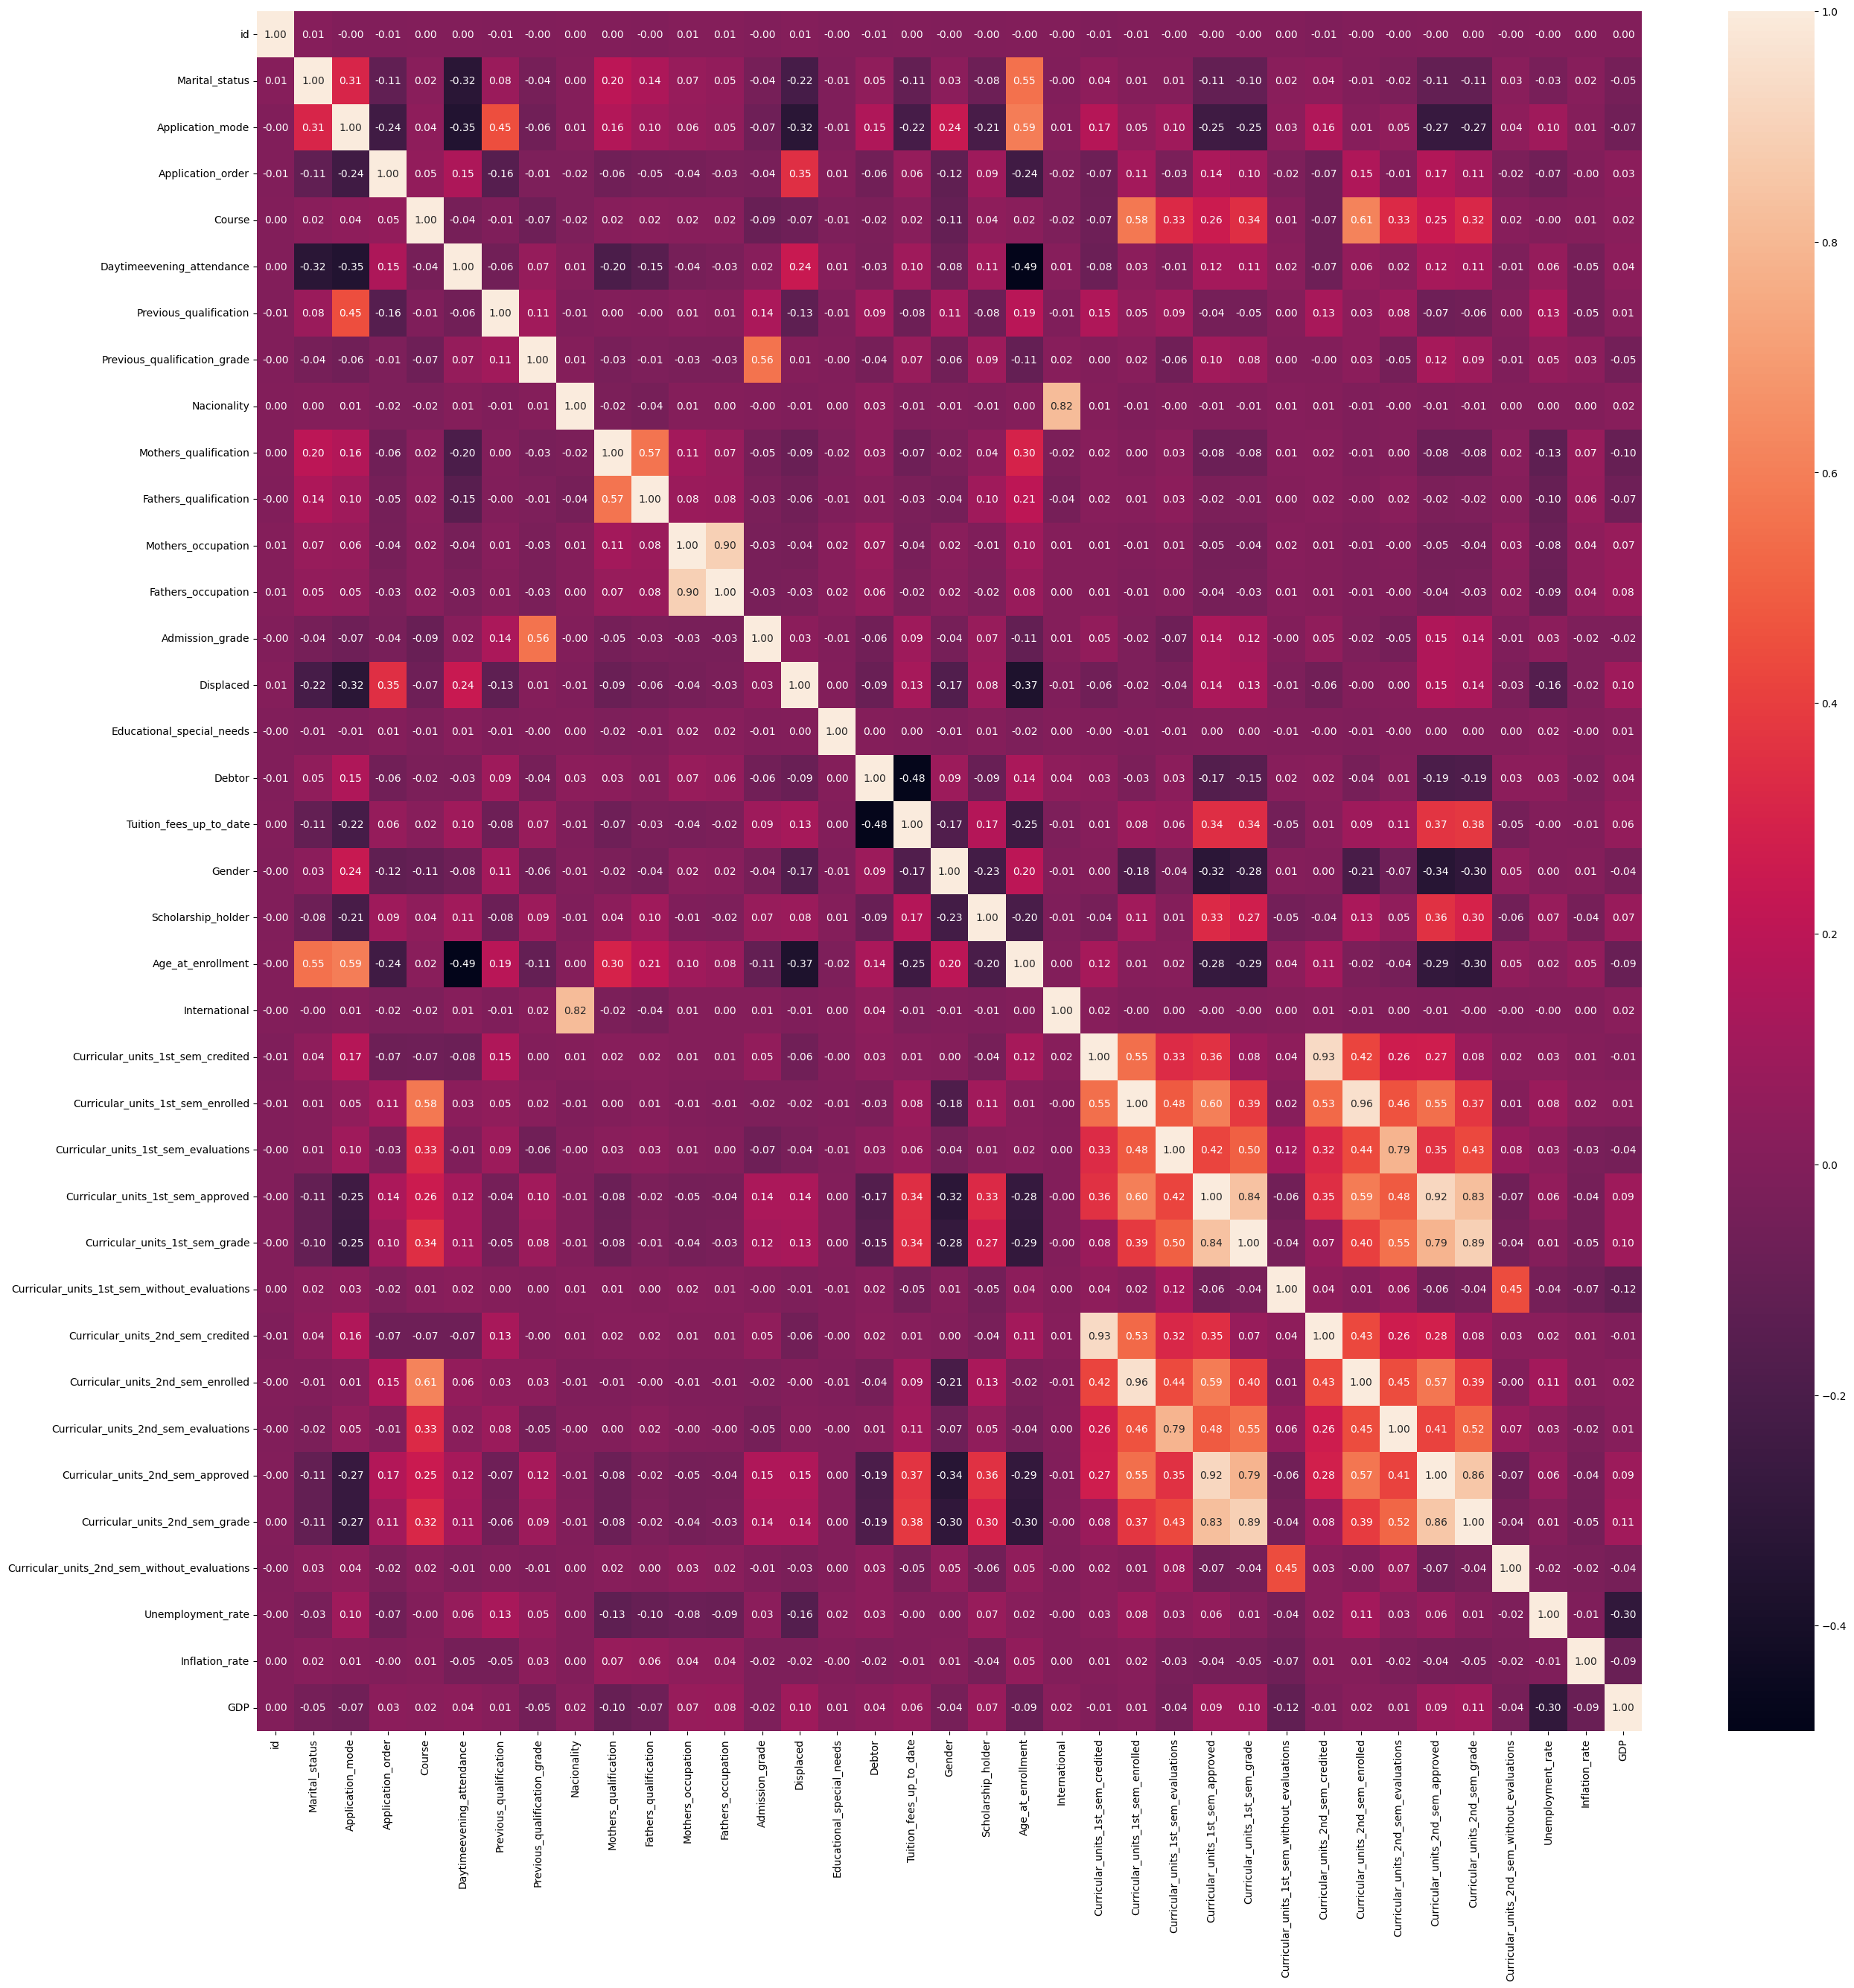

In [11]:
# look at heatmap
corr_df= x_train.corr()
fig2= plt.figure(figsize= (30, 30))
sns.heatmap(corr_df, annot= True, fmt= '.2f')

Some features have strong correlation.  Try removing some features to prevent multicollinearity.

In [12]:
# drop columns to prevent multicollinearity
drop_cols= ['id', 'International', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_approved', 'Curricular_units_2nd_sem_evaluations']

# drop columns
x_train= x_train.drop(drop_cols, axis= 1)

# verify columns were dropped
print(x_train.head())
print('new shape of x_train is: {}'.format(x_train.shape))

   Marital_status  Application_mode  Application_order  Course  \
0               1                 1                  1    9238   
1               1                17                  1    9238   
2               1                17                  2    9254   
3               1                 1                  3    9500   
4               1                 1                  2    9500   

   Daytimeevening_attendance  Previous_qualification  \
0                          1                       1   
1                          1                       1   
2                          1                       1   
3                          1                       1   
4                          1                       1   

   Previous_qualification_grade  Nacionality  Mothers_qualification  \
0                         126.0            1                      1   
1                         125.0            1                     19   
2                         137.0            1         

In [13]:
# function to split data, train model, predict and evaluate model

def metric_fn(train_x, test_x, train_y, test_y):
    params = {'n_estimators': 300, 'n_jobs': n_jobs, 'seed': 24, 
              'verbose':-1, 'class_weight': 'balanced', 'objective':'multiclass'}
    gbm = LGBMClassifier(**params)
    gbm.fit(train_x, train_y)
    pred = pd.DataFrame(gbm.predict(test_x), index=test_x.index)
    score = accuracy_score(test_y, pred)
    return score


In [14]:
score_list= []
feat_list= []


n_jobs = 4

train_x, val_x, train_y, val_y = train_test_split(x_train, y_train, test_size=0.2, random_state= 24, stratify= y_train, shuffle= True)
# get baseline score
score = metric_fn(train_x= train_x, test_x= val_x, train_y= train_y, test_y= val_y)
print("The accuracy before feature generation is", score)
# feature generation
ofe = OpenFE()
features= ofe.fit(data= train_x, label= train_y, n_jobs= n_jobs)

# check accuracy for range of new features 
for i in range(20):
    j= int(5 * i)
    train1, val1= transform(train_x, val_x, features[:j], n_jobs= n_jobs)
    score1= metric_fn(train1, val1, train_y, val_y)
    score_list.append(score1)
    feat_list.append(j)
    if i % 10 == 0:
        print('cycle {} is done'.format(i))



The accuracy before feature generation is 0.8175640355462624
The number of candidate features is 9980
Start stage I selection.


100%|██████████| 16/16 [04:59<00:00, 18.69s/it]


3550 same features have been deleted.


100%|██████████| 16/16 [03:55<00:00, 14.74s/it]


Meet early-stopping in successive feature-wise halving.


100%|██████████| 16/16 [11:12<00:00, 42.05s/it]


The number of remaining candidate features is 2000
Start stage II selection.


100%|██████████| 16/16 [01:18<00:00,  4.92s/it]


Finish data processing.
cycle 0 is done
cycle 10 is done


Text(0.5, 0, 'num. features')

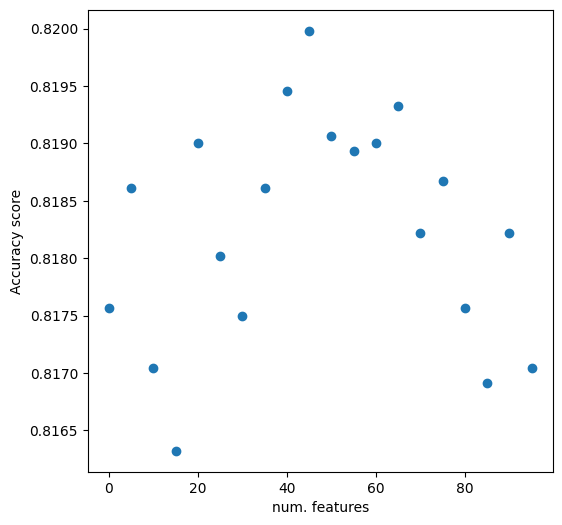

In [15]:
fig2= plt.figure(figsize= (6, 6))
ax2= plt.gca()
ax2.scatter(feat_list, score_list)
ax2.set_ylabel('Accuracy score')
ax2.set_xlabel('num. features')

In [16]:
# read in test data
test_df= pd.read_csv('/kaggle/input/playground-series-s4e6/test.csv')

print(test_df.head())
print('shape of test dataframe is: {}'.format(test_df.shape))

# separate id column
test_id= test_df['id']


      id  Marital status  Application mode  Application order  Course  \
0  76518               1                 1                  1    9500   
1  76519               1                 1                  1    9238   
2  76520               1                 1                  1    9238   
3  76521               1                44                  1    9147   
4  76522               1                39                  1    9670   

   Daytime/evening attendance  Previous qualification  \
0                           1                       1   
1                           1                       1   
2                           1                       1   
3                           1                      39   
4                           1                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  ...  \
0                           141.0            1                       3  ...   
1                           128.0            1              

In [17]:
# check for null in test dataframe
test_df.isnull().sum()

id                                                0
Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship 

No nulls in test dataframe

In [18]:
# fix test dataframe column names
test_df.columns= test_df.columns.str.replace(" ", "_")
test_df.columns= test_df.columns.str.replace(")", "")
test_df.columns= test_df.columns.str.replace("(", "")
test_df.columns= test_df.columns.str.replace("'", "")
test_df.columns= test_df.columns.str.replace("/", "")

In [19]:
# drop same columns as test
test_df= test_df.drop(drop_cols, axis= 1)

In [20]:
# automatically choose number of new features with highest accuracy
zip_list= zip(feat_list, score_list)

max_pair= max(zip_list, key= lambda x: x[1])

best_num_features= max_pair[0]

print('number of new features added is: {}'.format(best_num_features))

number of new features added is: 45


In [21]:
# transform train and test with new features

new_train, new_test= transform(x_train, test_df, new_features_list= features[:best_num_features], n_jobs= n_jobs)

new_train= new_train.reset_index(drop= True)
new_test= new_test.reset_index(drop= True)

print(new_train.shape)
print(new_train.head())


(76518, 77)
   Marital_status  Application_mode  Application_order  Course  \
0               1                 1                  1    9238   
1               1                17                  1    9238   
2               1                17                  2    9254   
3               1                 1                  3    9500   
4               1                 1                  2    9500   

   Daytimeevening_attendance  Previous_qualification  \
0                          1                       1   
1                          1                       1   
2                          1                       1   
3                          1                       1   
4                          1                       1   

   Previous_qualification_grade  Nacionality  Mothers_qualification  \
0                         126.0            1                      1   
1                         125.0            1                     19   
2                         137.0          

In [22]:
 # remove columns with null
new_train= new_train.dropna(axis= 1)
print('shape of new_train is: {}'.format(new_train.shape))

train_cols= new_train.columns

new_test= new_test.loc[:, train_cols]
print(new_test.isnull().sum().sum())

shape of new_train is: (76518, 62)
0


In [23]:
# convert categorical to numeric
str_col= new_train.select_dtypes(exclude= np.number).columns
num_col= new_train.select_dtypes(include= np.number).columns

if len(str_col) > 0:
    onehot= OneHotEncoder(handle_unknown= 'ignore', sparse_output= False)
    train_encoded= onehot.fit_transform(new_train[str_col])
    train_encoded= pd.DataFrame(train_encoded, columns= onehot.get_feature_names_out())
    
    test_encoded= onehot.transform(new_test[str_col])
    test_encoded= pd.DataFrame(test_encoded, columns= onehot.get_feature_names_out())
    
    
    train_encoded= pd.concat([new_train[num_col], train_encoded], axis= 1)
    test_encoded= pd.concat([new_test[num_col], test_encoded], axis= 1)

In [24]:
# transform the skewed data
# log for positive and exp for negative

try:
    train_trans= train_encoded.copy()
    test_trans= test_encoded.copy()
except NameError:
    train_trans= new_train.copy()
    test_trans= new_test.copy()    
    
# transform training data
for i in train_encoded.columns:
    if train_encoded[i].skew() > 1:
        min1= train_encoded[i].min()
        if min1 < 0:
            train_trans[i] = np.log(1 - min1 + train_encoded[i])
        else:
            train_trans[i]= np.log(1 + train_encoded[i])
    elif train_encoded[i].skew() < 1:
        train_trans[i]= (train_encoded[i])**2

# transform test data
for i in test_encoded.columns:
    if test_encoded[i].skew() > 1:
        min2= test_encoded[i].min()
        if min2 < 0:
            test_trans[i]= np.log(1 - min2 + test_encoded[i])
        else:
            test_trans[i]= np.log(1 + test_encoded[i])
        test_trans[i] = np.log(1 + test_encoded[i])
    elif test_encoded[i].skew() < 1:
        test_trans[i]= (test_encoded[i])**2

In [25]:
# scale data
scaler= MinMaxScaler()
train_scaled= scaler.fit_transform(train_trans)
train_scaled= pd.DataFrame(train_scaled, columns= train_encoded.columns)

test_scaled= scaler.transform(test_trans)
test_scaled= pd.DataFrame(test_scaled, columns= test_encoded.columns)

In [26]:
# make empty arrays for holding predictions
pred1= np.zeros(x_train.shape[0])
pred1= pd.Series(pred1, name= 'lightgbm')
pred2= np.zeros(x_train.shape[0])
pred2= pd.Series(pred2, name= 'forest')
pred3= np.zeros(x_train.shape[0])
pred3= pd.Series(pred3, name= 'xgboost')


In [27]:
# make empty arrays for holding test predictions
test_pred1= np.zeros(new_test.shape[0])
test_pred1= pd.Series(test_pred1, name= 'lightgbm')
test_pred2= np.zeros(new_test.shape[0])
test_pred2= pd.Series(test_pred2, name= 'forest')
test_pred3= np.zeros(new_test.shape[0])
test_pred3= pd.Series(test_pred3, name= 'xgboost')


In [28]:
# hyperparameter tuning xgboost

def objective1(trial):
    param1= trial.suggest_float('learning_rate', 0.001, 0.07)
    param2= trial.suggest_float('subsample', 0.75, 1.0)
    param3= trial.suggest_int('n_estimators', 700, 1200)

    clf1= XGBClassifier(learning_rate= param1, subsample= param2, n_estimators= param3,
                        random_state= 24, objective= 'multi:softmax', num_class= 3, verbose= 1)

    sample_weights= compute_sample_weight('balanced', y_train)
    
    score= cross_val_score(clf1, train_scaled, y_train, cv= 3, params= {'sample_weight':sample_weights}).mean()
    
    return score

study_boost= optuna.create_study(direction= 'maximize')
study_boost.optimize(objective1, n_trials= 30)

print('best score for xgboost was: {}'.format(study_boost.best_trial.value))
print('best parameters for xgboost were: {}'.format(study_boost.best_trial.params))

[I 2026-03-22 01:11:26,671] A new study created in memory with name: no-name-023f48e6-3495-4aa3-87bc-285ef016e4a3
[I 2026-03-22 01:12:29,819] Trial 0 finished with value: 0.8193104890352597 and parameters: {'learning_rate': 0.03579831671797449, 'subsample': 0.7734966727408751, 'n_estimators': 888}. Best is trial 0 with value: 0.8193104890352597.
[I 2026-03-22 01:13:29,376] Trial 1 finished with value: 0.81991165477404 and parameters: {'learning_rate': 0.055024776363202924, 'subsample': 0.9461576126359794, 'n_estimators': 907}. Best is trial 1 with value: 0.81991165477404.
[I 2026-03-22 01:14:47,589] Trial 2 finished with value: 0.8200554117985311 and parameters: {'learning_rate': 0.05764536033085282, 'subsample': 0.8993813131933265, 'n_estimators': 1172}. Best is trial 2 with value: 0.8200554117985311.
[I 2026-03-22 01:16:04,376] Trial 3 finished with value: 0.817389372435244 and parameters: {'learning_rate': 0.014267366637965618, 'subsample': 0.7913054606130717, 'n_estimators': 1043}.

best score for xgboost was: 0.8207088528189446
best parameters for xgboost were: {'learning_rate': 0.060434572577814955, 'subsample': 0.9115014718261626, 'n_estimators': 974}


In [29]:
# hyperparameter tuning lightgbm

def objective2(trial):
    param1= trial.suggest_float('learning_rate', 0.001, 0.07)
    param2= trial.suggest_int('num_leaves', 20, 150)
    param3= trial.suggest_int('num_iterations', 300, 700)

    clf2= LGBMClassifier(learning_rate= param1, num_leaves= param2, num_iterations= param3,
                        random_state= 24, objective= 'multiclass', verbose= 0, class_weight= 'balanced')

    score= cross_val_score(clf2, train_scaled, y_train, cv= 3).mean()
    return score

study_light= optuna.create_study(direction= 'maximize')
study_light.optimize(objective2, n_trials= 30)

print('best score for lightgbm was: {}'.format(study_light.best_trial.value))
print('best parameters for lightgbm were: {}'.format(study_light.best_trial.params))

[I 2026-03-22 01:46:18,224] A new study created in memory with name: no-name-ede90fc9-3a84-43d7-8234-93447f028c24
[I 2026-03-22 01:46:53,992] Trial 0 finished with value: 0.818212708120965 and parameters: {'learning_rate': 0.04556150711187446, 'num_leaves': 55, 'num_iterations': 433}. Best is trial 0 with value: 0.818212708120965.
[I 2026-03-22 01:47:13,622] Trial 1 finished with value: 0.8161086280352335 and parameters: {'learning_rate': 0.057682956177903026, 'num_leaves': 28, 'num_iterations': 304}. Best is trial 0 with value: 0.818212708120965.
[I 2026-03-22 01:47:45,390] Trial 2 finished with value: 0.8103060717739616 and parameters: {'learning_rate': 0.0073854420277737, 'num_leaves': 34, 'num_iterations': 372}. Best is trial 0 with value: 0.818212708120965.
[I 2026-03-22 01:48:20,845] Trial 3 finished with value: 0.8149977783005306 and parameters: {'learning_rate': 0.017828210518164866, 'num_leaves': 67, 'num_iterations': 329}. Best is trial 0 with value: 0.818212708120965.
[I 202

best score for lightgbm was: 0.8221072166026294
best parameters for lightgbm were: {'learning_rate': 0.06900139732018472, 'num_leaves': 129, 'num_iterations': 576}


In [30]:
# use cross validation to make predictions with base models

cv5= StratifiedKFold(n_splits= 5, random_state= 24, shuffle= True)

# initialize counter
count1= 1
for train_id, val_id in cv5.split(train_scaled, y_train):
    xtrain1= train_scaled.iloc[train_id, :]
    xval1= train_scaled.iloc[val_id, :]
    ytrain1= y_train[train_id]
    yval1= y_train[val_id]

    print('fold {}'.format(count1))
    # model 1- lightgbm
    light2= LGBMClassifier(random_state= 24, verbose= -1, class_weight= 'balanced', objective= 'multiclass', 
        learning_rate= study_light.best_trial.params['learning_rate'], 
        num_leaves= study_light.best_trial.params['num_leaves'], 
        num_iterations= study_light.best_trial.params['num_iterations'])
    light2.fit(xtrain1, ytrain1)
    # predictions
    pred1.iloc[val_id]= light2.predict(xval1)
    # evaluate
    score1= accuracy_score(yval1, pred1.iloc[val_id])
    print('accuracy for lightgbm model is: {}'.format(np.round(score1, 3)))
    # test predictions
    test1= (light2.predict(test_scaled))/cv5.n_splits
    test1= pd.Series(test1, name= 'lightgbm')
    test_pred1= test1 + test_pred1
    

    # model 2- Random Forest
    forest2= RandomForestClassifier(random_state= 24, class_weight= 'balanced', criterion= 'entropy')
    forest2.fit(xtrain1, ytrain1)
    # predictions
    pred2.iloc[val_id]= forest2.predict(xval1)
    # evaluate
    score2= accuracy_score(yval1, pred2.iloc[val_id])
    print('accuracy for random forest model is: {}'.format(np.round(score2, 3)))
    # test predictions
    test2= (forest2.predict(test_scaled))/cv5.n_splits
    test2= pd.Series(test2, name= 'forest')
    test_pred2= test_pred2 + test2


    # model 3- xgboost
    boost2= XGBClassifier(random_state= 24, objective= 'multi:softmax', num_class= 3, 
        learning_rate= study_boost.best_trial.params['learning_rate'], 
        n_estimators= study_boost.best_trial.params['n_estimators'], 
        subsample= study_boost.best_trial.params['subsample'])
    sample_weight2= compute_sample_weight('balanced', ytrain1)
    boost2.fit(xtrain1, ytrain1, sample_weight= sample_weight2)
    # predictions
    pred3.iloc[val_id]= boost2.predict(xval1)
    # evaluate
    score3= accuracy_score(yval1, pred3.iloc[val_id])
    print('accuracy for xgboost model is: {}'.format(np.round(score3, 3)))
    # test predictions
    test3= (boost2.predict(test_scaled))/cv5.n_splits
    test3= pd.Series(test3, name= 'xgboost')
    test_pred3= test_pred3 + test3


    count1= count1 + 1



fold 1
accuracy for lightgbm model is: 0.826
accuracy for random forest model is: 0.826
accuracy for xgboost model is: 0.825
fold 2
accuracy for lightgbm model is: 0.819
accuracy for random forest model is: 0.822
accuracy for xgboost model is: 0.818
fold 3
accuracy for lightgbm model is: 0.821
accuracy for random forest model is: 0.824
accuracy for xgboost model is: 0.821
fold 4
accuracy for lightgbm model is: 0.822
accuracy for random forest model is: 0.822
accuracy for xgboost model is: 0.82
fold 5
accuracy for lightgbm model is: 0.821
accuracy for random forest model is: 0.821
accuracy for xgboost model is: 0.817


In [31]:
# combine predictions from base models, will use to train meta model
base_pred_all= pd.concat([pred1, pred2, pred3], axis= 1)

In [32]:
# combine predictions from base models on test data, features for meta model prediction
test_pred_all= pd.concat([test_pred1, test_pred2, test_pred3], axis= 1)

In [33]:
# make final predictions
# meta model
logreg= LogisticRegression(multi_class= 'multinomial', solver= 'lbfgs')
logreg.fit(base_pred_all, y_train)

# predictions on test
y_meta_pred= logreg.predict(test_pred_all)
y_meta_pred= pd.Series(y_meta_pred, name= 'Target')
# convert from int to labels
y_pred_final= encoder.inverse_transform(y_meta_pred)
y_pred_final= pd.Series(y_pred_final, name= 'Target')
# add id column
y_pred_final= pd.concat([test_id, y_pred_final], axis= 1)

    

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [34]:
# submit to competition
sub_df= y_pred_final.to_csv('/kaggle/working/submission.csv', index= False)